In [1]:
import sqlite3
import pandas as pd

In [2]:
db_path="./archive/database.sqlite"
conn=sqlite3.connect(db_path)

In [3]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """, conn)

tables

,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


Za potrebe klasterovanja izabrana je tabela Player_Attributes, jer sadrži detaljne numeričke atribute igrača koji opisuju njihove tehničke, fizičke i golmanske karakteristike. Ovakav skup obeležja omogućava prirodno grupisanje igrača prema sličnom stilu igre i ulozi na terenu.

In [4]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)

print(df.shape)
df.head()

(183978, 42)


,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

attacking_work_rate    3230
volleys                2713
agility                2713
sliding_tackle         2713
vision                 2713
jumping                2713
curve                  2713
balance                2713
defensive_work_rate     836
potential               836
shot_power              836
reactions               836
long_shots              836
stamina                 836
overall_rating          836
preferred_foot          836
crossing                836
short_passing           836
long_passing            836
free_kick_accuracy      836
dtype: int64

Izbacimo atribute koji ce praviti sumove u klasterima

In [6]:
df = df.drop(columns=[
    'id',
    'player_fifa_api_id',
    'player_api_id',
    'date'
])

Baza ima puno redova, pa mozemo da obrisemo one sa NV

In [7]:
df = df.dropna()

print(df.shape)

(180354, 38)


In [8]:
df['preferred_foot'] = df['preferred_foot'].map({
    'left': 0,
    'right': 1
})

In [9]:
print(df['attacking_work_rate'].unique())
print(df['defensive_work_rate'].unique())

['medium' 'high' 'low' 'None' 'le' 'norm' 'stoc' 'y']
['medium' 'high' 'low' '5' 'ean' 'o' '1' 'ormal' '7' '2' '8' '4' 'tocky'
 '0' '3' '6' '9' 'es']


In [10]:
valid_values = ['low', 'medium', 'high']

df = df[
    df['attacking_work_rate'].isin(valid_values) &
    df['defensive_work_rate'].isin(valid_values)
]

In [11]:
df = pd.get_dummies(
    df,
    columns=['attacking_work_rate', 'defensive_work_rate'],
    dtype=int
)

In [12]:
print(df.shape)
df.head()

(176161, 42)


,overall_rating,potential,preferred_foot,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,...,gk_handling,gk_kicking,gk_positioning,gk_reflexes,attacking_work_rate_high,attacking_work_rate_low,attacking_work_rate_medium,defensive_work_rate_high,defensive_work_rate_low,defensive_work_rate_medium
0,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
1,67.0,71.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
2,62.0,66.0,1,49.0,44.0,71.0,61.0,44.0,51.0,45.0,...,11.0,10.0,8.0,8.0,0,0,1,0,0,1
3,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1
4,61.0,65.0,1,48.0,43.0,70.0,60.0,43.0,50.0,44.0,...,10.0,9.0,7.0,7.0,0,0,1,0,0,1


In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

Hocu prvo da vidim koliko je najbolje klastera da imam

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

In [16]:
inertia = []
sil_scores = []

K = range(2, 11)

n_sample = 3000

if X_scaled.shape[0] > n_sample:
    np.random.seed(19)
    idx = np.random.choice(X_scaled.shape[0], n_sample, replace=False)
    X_sil = X_scaled[idx]
else:
    X_sil = X_scaled

In [17]:
for k in K:
    model = KMeans(n_clusters=k, random_state=19, n_init=10)
    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)

    # silhouette samo na uzorku
    if X_scaled.shape[0] > n_sample:
        sample_labels = model.predict(X_sil)
        sil_scores.append(silhouette_score(X_sil, sample_labels))
    else:
        sil_scores.append(silhouette_score(X_scaled, labels))

Parametar n_init=10 korišćen je kako bi algoritam K-sredina bio pokrenut više puta sa različitim slučajnim početnim centroidima, nakon čega je izabrano rešenje sa najmanjom vrednošću SSE.

In [18]:
import matplotlib.pyplot as plt

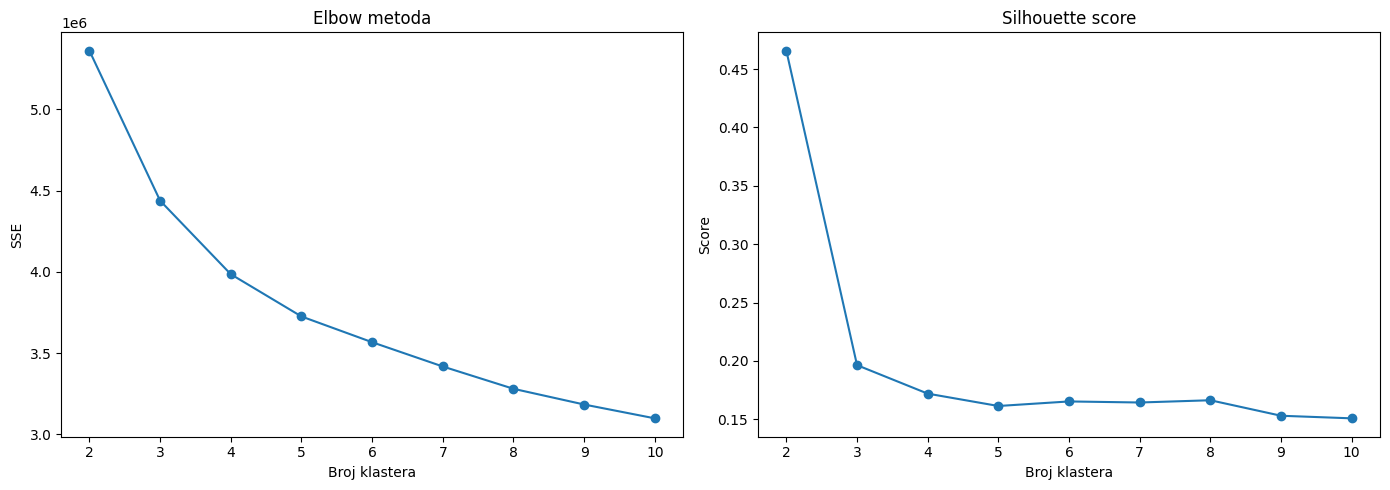

In [19]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.title("Elbow metoda")
plt.xlabel("Broj klastera")
plt.ylabel("SSE")

plt.subplot(1,2,2)
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score")
plt.xlabel("Broj klastera")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

Elbow metoda ukazuje na prelomnu tačku oko 4 klastera, dok silueta koeficijent ima maksimum za 2 klastera. Iako bi izbor 2 klastera dao najbolju kompaktnost, takva podela najverovatnije odvaja golmane od svih ostalih igrača. Zbog bolje interpretabilnosti i prirodne podele fudbalera prema ulozi na terenu, za dalju analizu izabran je broj klastera k=4.

Za klasterovanje koristicemo sledece algoritme:
1. K-means (K-sredina)
2. Hijerarhijsko klasterovanje
3. GMM (Gaussian Mixture Model, Modeli Gausovih mešavina) - slican kao K-means, ali fleksibilniji
4. Birch
5. DBSCAN

In [20]:
from sklearn.cluster import KMeans

In [21]:
kmeans = KMeans(n_clusters=4, random_state=19, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_scaled)

In [22]:
df['KMeans_cluster'] = clusters_kmeans
df[['overall_rating', 'potential', 'KMeans_cluster']].head(10)

,overall_rating,potential,KMeans_cluster
0,67.0,71.0,3
1,67.0,71.0,3
2,62.0,66.0,3
3,61.0,65.0,3
4,61.0,65.0,3
5,74.0,76.0,1
6,74.0,76.0,1
7,73.0,75.0,1
8,73.0,75.0,1
9,73.0,75.0,1


In [23]:
df['KMeans_cluster'].value_counts().sort_index()

KMeans_cluster
0    62153
1    50183
2    14299
3    49526
Name: count, dtype: int64

K-sredina sa 4 klastera formirala je tri velika klastera igrača u polju i jedan značajno manji klaster koji najverovatnije odgovara golmanima.

In [24]:
from sklearn.decomposition import PCA

In [25]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [26]:
print(pca.explained_variance_ratio_)
print("Ukupno sačuvano:", pca.explained_variance_ratio_.sum())

[0.38350528 0.13983574]
Ukupno sačuvano: 0.5233410209228113


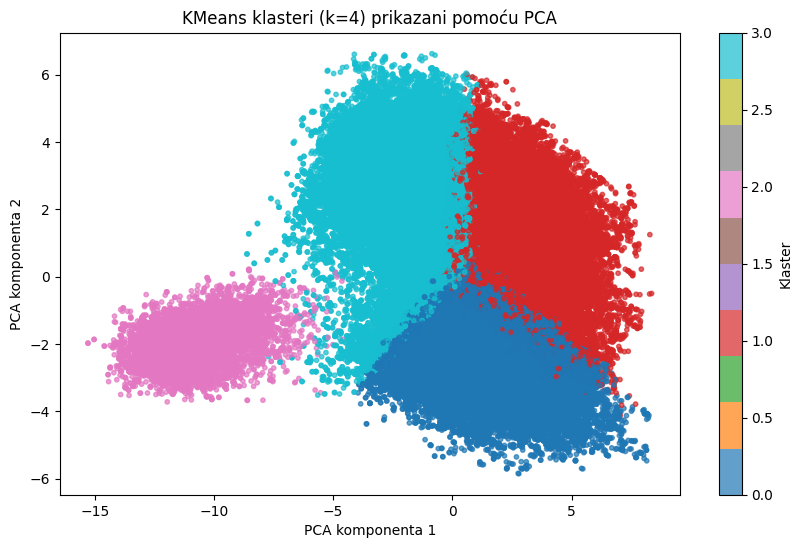

In [27]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['KMeans_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("KMeans klasteri (k=4) prikazani pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

Na PCA 2D prikazu klastera dobijenih algoritmom K-sredina sa 4 klastera uočava se jedna potpuno izdvojena grupa igrača, koja najverovatnije odgovara golmanima. Preostala tri klastera predstavljaju igrače u polju i mogu se interpretirati kao odbrambeni, vezni i napadački profili. Delimično preklapanje u centralnom delu prostora je očekivano zbog sličnosti pojedinih uloga na terenu.

In [28]:
cluster_means = df.groupby('KMeans_cluster').mean()

cluster_means[['overall_rating', 'potential']].round(2)

,overall_rating,potential
KMeans_cluster,,
0,69.07,74.28
1,72.77,76.50
2,68.21,72.53
3,64.22,69.82


In [29]:
from sklearn.cluster import AgglomerativeClustering

Za hijerarhijsko klasterovanje ovo je prevelika baza, radimo na uzorku

In [30]:
np.random.seed(19)

n_hc = 5000
idx_hc = np.random.choice(X_scaled.shape[0], n_hc, replace=False)

X_hc = X_scaled[idx_hc]

In [31]:
hc = AgglomerativeClustering(n_clusters=4)
clusters_hc = hc.fit_predict(X_hc)

In [32]:
X_pca_hc = X_pca[idx_hc]

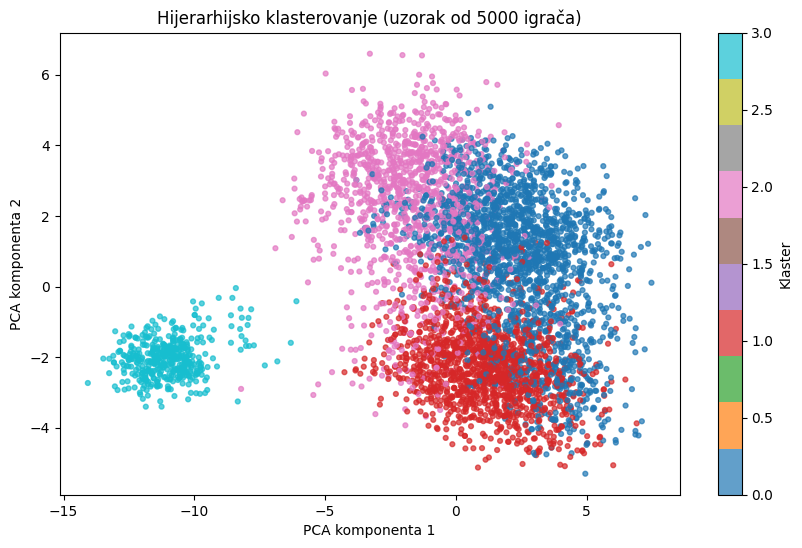

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_hc[:, 0],
    X_pca_hc[:, 1],
    c=clusters_hc,
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("Hijerarhijsko klasterovanje (uzorak od 5000 igrača)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

I K-sredina i hijerarhijsko klasterovanje dosledno izdvajaju jedan mali i jasno separisan klaster, koji odgovara golmanima. Preostala tri klastera predstavljaju igrače u polju, pri čemu hijerarhijski pristup pokazuje nešto veće preklapanje u centralnom delu prostora.

In [34]:
pd.Series(clusters_hc).value_counts().sort_index()

0    1945
1    1442
2    1178
3     435
Name: count, dtype: int64

In [35]:
from sklearn.mixture import GaussianMixture

In [36]:
gmm = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
)

clusters_gmm = gmm.fit_predict(X_scaled)

covariance_type='full' - Ovo je veoma važno.
Znači da svaki klaster može imati svoj oblik, širinu i orijentaciju.
Dakle nije ograničen na “okrugle” klastere kao KMeans.
To je baš prednost GMM-a.

In [37]:
df['GMM_cluster'] = clusters_gmm
df['GMM_cluster'].value_counts().sort_index()

GMM_cluster
0    14298
1    93335
2    49853
3    18675
Name: count, dtype: int64

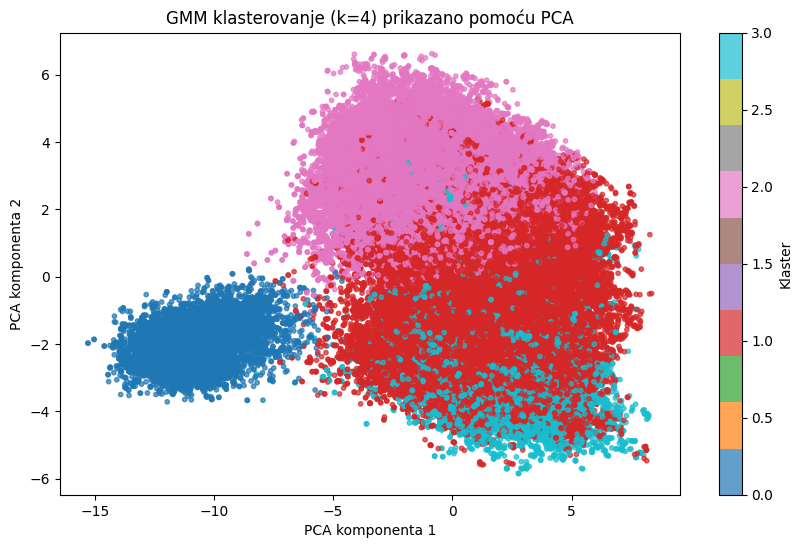

In [38]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['GMM_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("GMM klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

Za razliku od K-sredina algoritma, GMM pokazuje mekše prelaze između centralnih klastera, što bolje odražava postojanje hibridnih fudbalskih uloga, kao što su ofanzivni vezni ili bekovi sa izraženim napadačkim karakteristikama.

In [39]:
from sklearn.cluster import Birch

In [40]:
for t in [2.0, 2.5, 3.0, 3.5]:
    birch = Birch(n_clusters=None, threshold=t)
    birch.fit(X_scaled)
    print(f"threshold={t} -> broj podklastera: {len(birch.subcluster_centers_)}")

threshold=2.0 -> broj podklastera: 20613
threshold=2.5 -> broj podklastera: 9226
threshold=3.0 -> broj podklastera: 2998
threshold=3.5 -> broj podklastera: 898


In [41]:
birch = Birch(n_clusters=None, threshold=3.0)
birch.fit(X_scaled)

,threshold,3.0
,branching_factor,50
,n_clusters,None
,compute_labels,True
,copy,'deprecated'


In [42]:
kmeans_sub = KMeans(n_clusters=4, random_state=19, n_init=10)
subcluster_labels = kmeans_sub.fit_predict(birch.subcluster_centers_)

In [43]:
subcluster_index_for_each_row = birch.predict(X_scaled)

In [44]:
clusters_birch = subcluster_labels[subcluster_index_for_each_row]

In [45]:
df['Birch_cluster'] = clusters_birch

In [46]:
df['Birch_cluster'].value_counts().sort_index()

Birch_cluster
0    27076
1    14298
2    49887
3    84900
Name: count, dtype: int64

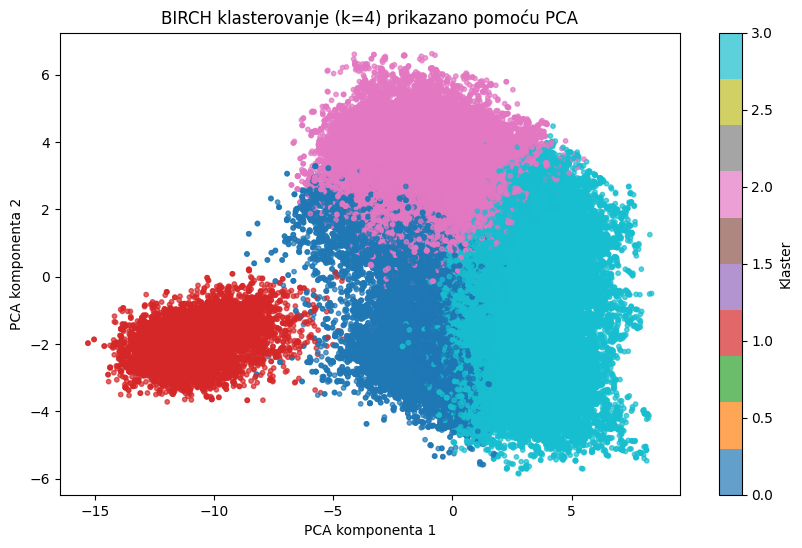

In [47]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Birch_cluster'],
    cmap='tab10',
    s=10,
    alpha=0.7
)

plt.title("BIRCH klasterovanje (k=4) prikazano pomoću PCA")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

BIRCH daje rezultat veoma sličan algoritmu K-sredina, pri čemu dosledno izdvaja mali i jasno separisan klaster golmana. Ovakvo ponašanje potvrđuje stabilnost strukture podataka i opravdanost izbora 4 klastera.


In [48]:
from sklearn.cluster import DBSCAN

In [49]:
np.random.seed(19)

n_db = 5000
idx_db = np.random.choice(X_scaled.shape[0], n_db, replace=False)

X_db = X_scaled[idx_db]
X_pca_db = X_pca[idx_db]

In [50]:
for eps in [2.5, 3.0, 3.5, 4.0, 4.5, 5.0]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=2.5
  broj klastera: 13
  broj šum tačaka: 4224
------------------------------
eps=3.0
  broj klastera: 13
  broj šum tačaka: 2323
------------------------------
eps=3.5
  broj klastera: 7
  broj šum tačaka: 999
------------------------------
eps=4.0
  broj klastera: 4
  broj šum tačaka: 407
------------------------------
eps=4.5
  broj klastera: 3
  broj šum tačaka: 142
------------------------------
eps=5.0
  broj klastera: 3
  broj šum tačaka: 47
------------------------------


In [51]:
for eps in [4.1, 4.2, 4.3, 4.4]:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"eps={eps}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

eps=4.1
  broj klastera: 4
  broj šum tačaka: 331
------------------------------
eps=4.2
  broj klastera: 4
  broj šum tačaka: 272
------------------------------
eps=4.3
  broj klastera: 3
  broj šum tačaka: 226
------------------------------
eps=4.4
  broj klastera: 3
  broj šum tačaka: 186
------------------------------


Biramo eps=4.2

In [52]:
dbscan = DBSCAN(eps=4.2, min_samples=10)
clusters_dbscan = dbscan.fit_predict(X_db)

In [53]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     272
 0    4181
 1      91
 2     391
 3      65
Name: count, dtype: int64

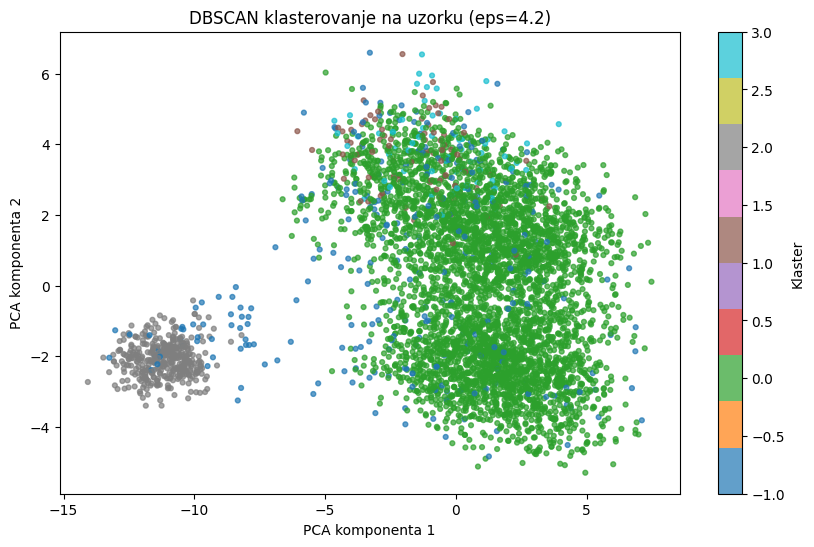

In [54]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_db[:, 0],
    X_pca_db[:, 1],
    c=clusters_dbscan,
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("DBSCAN klasterovanje na uzorku (eps=4.2)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

DBSCAN je izolovani region golmana označio kao šum, a ne kao poseban klaster. Iako su oni vizuelno jasno izdvojeni, njihova gustina u uzorku nije bila dovoljna da zadovolji uslov min_samples=10. Ovakav rezultat ukazuje da DBSCAN retke i veoma specifične profile igrača tretira kao outliere.

In [55]:
for min_s in [9, 8, 7, 6, 5, 4, 3, 2]:
    dbscan = DBSCAN(eps=4.2, min_samples=min_s)
    labels = dbscan.fit_predict(X_db)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(f"min_samples={min_s}")
    print(f"  broj klastera: {n_clusters}")
    print(f"  broj šum tačaka: {n_noise}")
    print("-" * 30)

min_samples=9
  broj klastera: 4
  broj šum tačaka: 259
------------------------------
min_samples=8
  broj klastera: 4
  broj šum tačaka: 245
------------------------------
min_samples=7
  broj klastera: 5
  broj šum tačaka: 233
------------------------------
min_samples=6
  broj klastera: 5
  broj šum tačaka: 226
------------------------------
min_samples=5
  broj klastera: 3
  broj šum tačaka: 218
------------------------------
min_samples=4
  broj klastera: 5
  broj šum tačaka: 194
------------------------------
min_samples=3
  broj klastera: 4
  broj šum tačaka: 188
------------------------------
min_samples=2
  broj klastera: 21
  broj šum tačaka: 154
------------------------------


uzimamo min_samples = 8

In [56]:
dbscan = DBSCAN(eps=4.2, min_samples=8)
clusters_dbscan = dbscan.fit_predict(X_db)

In [57]:
pd.Series(clusters_dbscan).value_counts().sort_index()

-1     245
 0    4189
 1      93
 2     400
 3      73
Name: count, dtype: int64

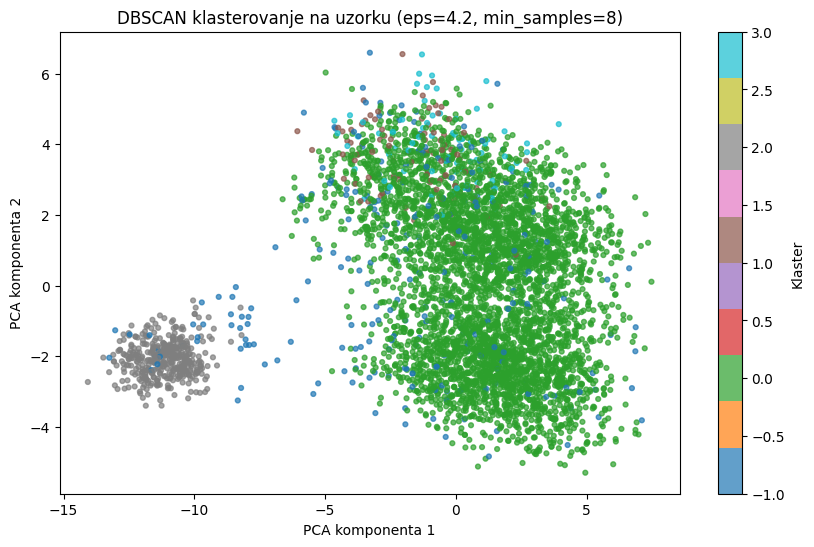

In [58]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_db[:, 0],
    X_pca_db[:, 1],
    c=clusters_dbscan,
    cmap='tab10',
    s=12,
    alpha=0.7
)

plt.title("DBSCAN klasterovanje na uzorku (eps=4.2, min_samples=8)")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

Parametri DBSCAN algoritma podešavani su na slučajnom uzorku od 5000 igrača. Kao optimalne vrednosti izabrani su eps=4.2 i min_samples=8, jer daju 4 klastera uz mali broj šum tačaka (245), što predstavlja najbolji kompromis između gustine i stabilnosti klastera.

In [59]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Zbog velike veličine skupa podataka, metrike kvaliteta klasterovanja računane su nad reprezentativnim slučajnim uzorkom od 5000 instanci.

In [60]:
np.random.seed(19)

n_eval = 5000
idx_eval = np.random.choice(X_scaled.shape[0], n_eval, replace=False)

X_eval = X_scaled[idx_eval]

In [61]:
rezultati = []

# KMeans
labels_kmeans = df["KMeans_cluster"].iloc[idx_eval]
rezultati.append([
    "KMeans",
    silhouette_score(X_eval, labels_kmeans),
    davies_bouldin_score(X_eval, labels_kmeans),
    calinski_harabasz_score(X_eval, labels_kmeans)
])

# GMM
labels_gmm = df["GMM_cluster"].iloc[idx_eval]
rezultati.append([
    "GMM",
    silhouette_score(X_eval, labels_gmm),
    davies_bouldin_score(X_eval, labels_gmm),
    calinski_harabasz_score(X_eval, labels_gmm)
])

# BIRCH
labels_birch = df["Birch_cluster"].iloc[idx_eval]
rezultati.append([
    "BIRCH",
    silhouette_score(X_eval, labels_birch),
    davies_bouldin_score(X_eval, labels_birch),
    calinski_harabasz_score(X_eval, labels_birch)
])

# HC
rezultati.append([
    "Hijerarhijsko",
    silhouette_score(X_hc, clusters_hc),
    davies_bouldin_score(X_hc, clusters_hc),
    calinski_harabasz_score(X_hc, clusters_hc)
])

# DBSCAN (bez šuma)
mask = clusters_dbscan != -1

rezultati.append([
    "DBSCAN",
    silhouette_score(X_db[mask], clusters_dbscan[mask]),
    davies_bouldin_score(X_db[mask], clusters_dbscan[mask]),
    calinski_harabasz_score(X_db[mask], clusters_dbscan[mask])
])

- Silhouette meri: koliko je tačka bliska svom klasteru, a daleka od drugih
- Davies-Bouldin gleda: odnos širine klastera i udaljenosti između klastera
- Calinski-Harabasz meri: odnos između razdvajanja klastera i zbijenosti unutar klastera


In [62]:
rez_df = pd.DataFrame(
    rezultati,
    columns=["Algoritam", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz"]
)

rez_df.sort_values("Silhouette", ascending=False)

,Algoritam,Silhouette,Davies-Bouldin,Calinski-Harabasz
4,DBSCAN,0.212016,1.613264,817.140663
0,KMeans,0.174894,1.741409,1497.299749
2,BIRCH,0.156430,1.748373,1371.873276
1,GMM,0.153289,1.924349,1212.063529
3,Hijerarhijsko,0.144116,1.979679,1305.792101


Iako DBSCAN postiže najbolje vrednosti Silhouette i Davies-Bouldin indeksa, ovaj algoritam izdvojeni region golmana tretira kao šum, što nije poželjno sa aspekta domenske interpretacije. Zbog toga se K-sredina pokazala kao najpogodniji algoritam, jer daje stabilnu podelu na četiri prirodne fudbalske uloge i jasno izdvaja golmane kao poseban klaster.


### Vizuelizacija nad istim uzorkom

In [63]:
np.random.seed(19)

n_vis = 5000
idx_vis = np.random.choice(X_scaled.shape[0], n_vis, replace=False)

X_vis = X_scaled[idx_vis]

# %%
pca_vis = PCA(n_components=2)
X_vis_pca = pca_vis.fit_transform(X_vis)

In [64]:
# KMeans
labels_kmeans_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(X_vis)

# Hijerarhijsko
labels_hc_vis = AgglomerativeClustering(n_clusters=4).fit_predict(X_vis)

# GMM
labels_gmm_vis = GaussianMixture(
    n_components=4,
    random_state=19,
    covariance_type='full'
).fit_predict(X_vis)

# BIRCH
birch_vis = Birch(n_clusters=None, threshold=3.0)
birch_vis.fit(X_vis)

sub_labels_vis = KMeans(n_clusters=4, random_state=19, n_init=10).fit_predict(
    birch_vis.subcluster_centers_
)
labels_birch_vis = sub_labels_vis[birch_vis.predict(X_vis)]

# DBSCAN
labels_dbscan_vis = DBSCAN(eps=4.2, min_samples=8).fit_predict(X_vis)

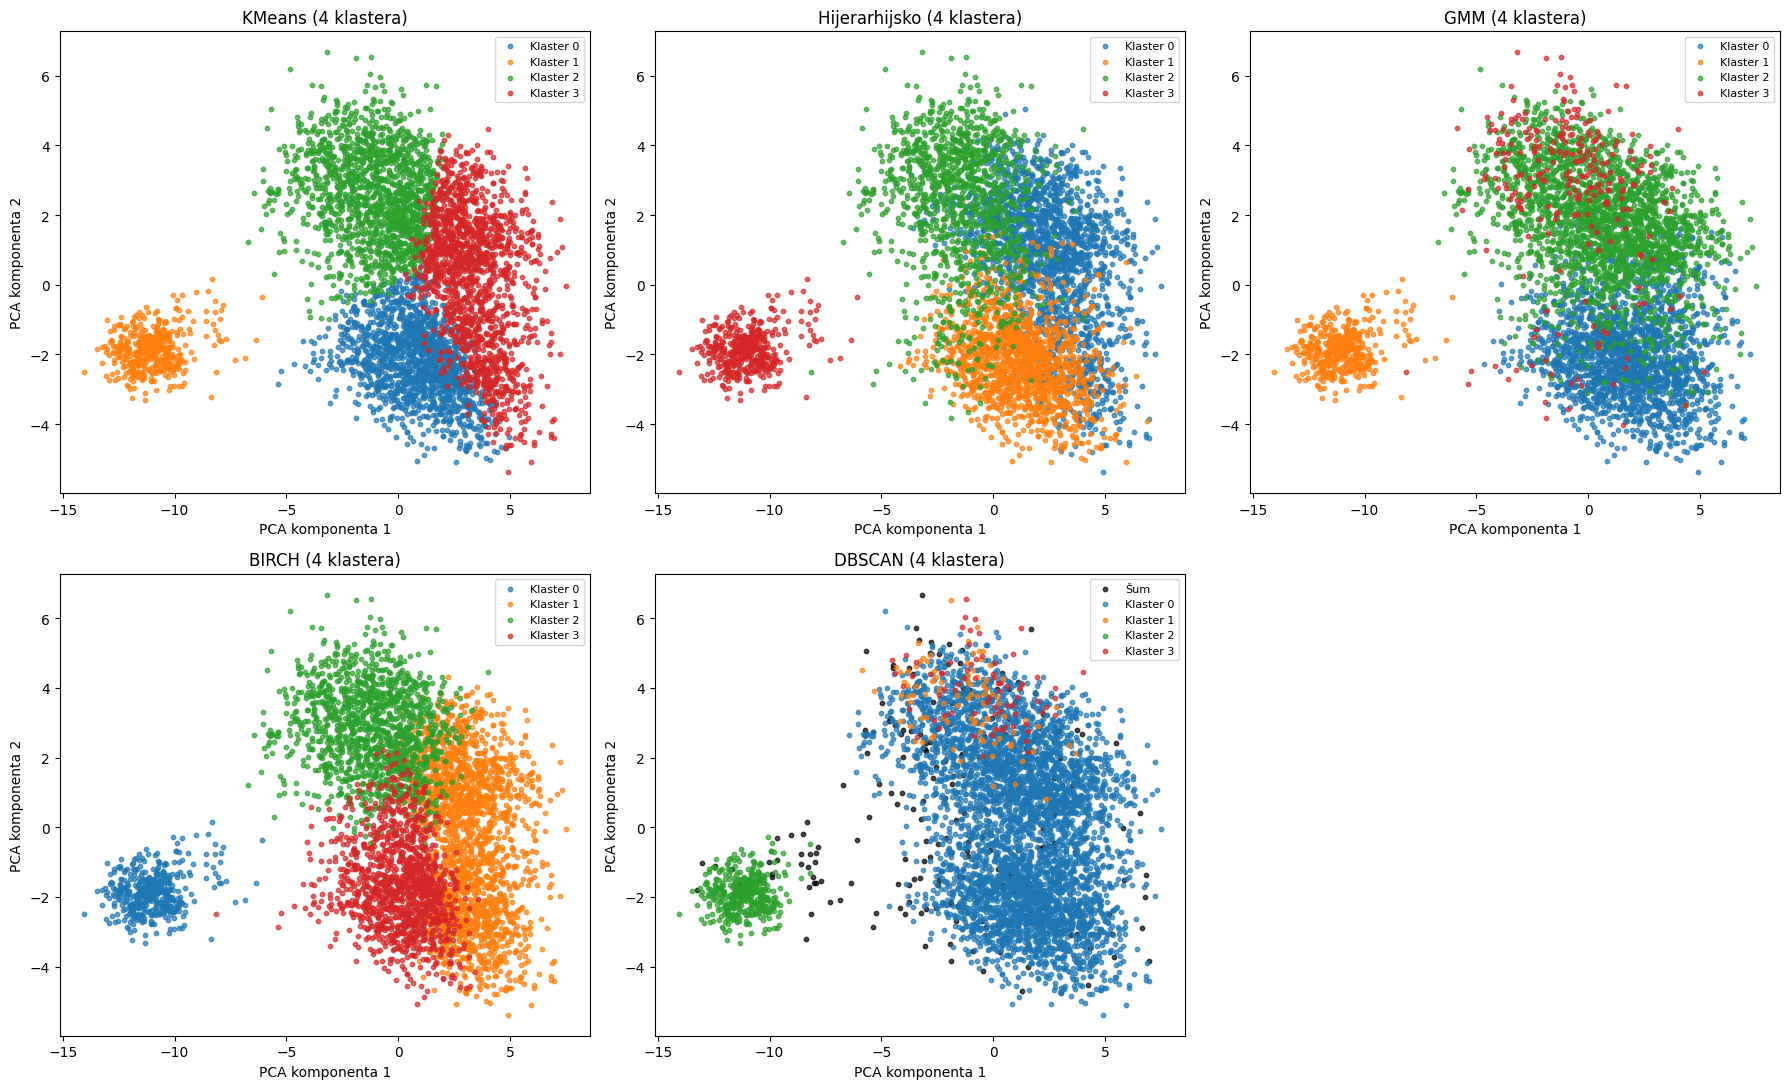

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

algorithms = [
    ("KMeans", labels_kmeans_vis),
    ("Hijerarhijsko", labels_hc_vis),
    ("GMM", labels_gmm_vis),
    ("BIRCH", labels_birch_vis),
    ("DBSCAN", labels_dbscan_vis),
]

for i, (name, labels) in enumerate(algorithms):
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab

        if lab == -1:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                c="black",
                alpha=0.7,
                label="Šum"
            )
        else:
            axes[i].scatter(
                X_vis_pca[mask, 0],
                X_vis_pca[mask, 1],
                s=10,
                alpha=0.7,
                label=f"Klaster {lab}"
            )

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    axes[i].set_title(f"{name} ({n_clusters} klastera)")
    axes[i].set_xlabel("PCA komponenta 1")
    axes[i].set_ylabel("PCA komponenta 2")
    axes[i].legend(fontsize=8)

# poslednji subplot je višak
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

- DBSCAN postiže najbolje interne metrike, ali je pokazao veću osetljivost na izbor uzorka i u pojedinim slučajevima tretira golmane kao šum. KMeans daje nešto slabije metričke vrednosti, ali pruža stabilniju i fudbalski prirodniju podelu na golmane, odbranu, vezni red i napad.
- Iako DBSCAN ostvaruje najbolje vrednosti Silhouette i Davies-Bouldin indeksa, K-sredina se pokazala kao najpogodniji model za praktičnu interpretaciju rezultata. Vizuelna analiza pokazuje da KMeans stabilno izdvaja golmane kao poseban klaster i formira tri dodatne prirodne grupe igrača u polju, što bolje odgovara domenskom znanju o fudbalskim ulogama.

### klasterovanje nad redukovanim atributima

Za ispitivanje uticaja redukcije dimenzionalnosti na kvalitet klasterovanja korišćen je K-sredina algoritam kao reprezentativni model, budući da se u prethodnoj analizi pokazao kao najstabilniji i najlakši za interpretaciju. Na ovaj način direktno je upoređen uticaj punog i redukovanog skupa atributa na kvalitet klastera.

In [66]:
pca_10 = PCA(n_components=10, random_state=19)
X_pca10 = pca_10.fit_transform(X_scaled)

In [67]:
print("Varijansa po komponentama:")
print(pca_10.explained_variance_ratio_)

print("Ukupno sačuvano:",
      pca_10.explained_variance_ratio_.sum())

Varijansa po komponentama:
[0.38350528 0.13983574 0.07641251 0.05045933 0.04760151 0.03713474
 0.0344219  0.02444485 0.02355945 0.02067623]
Ukupno sačuvano: 0.8380515306379429


In [68]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=19,
    n_init=10
)

clusters_kmeans_pca = kmeans_pca.fit_predict(X_pca10)

In [69]:
X_pca10_eval = X_pca10[idx_eval]
labels_pca_eval = clusters_kmeans_pca[idx_eval]

In [70]:
print("KMeans + PCA(10)")
print("Silhouette:",
      silhouette_score(X_pca10_eval, labels_pca_eval))
print("Davies-Bouldin:",
      davies_bouldin_score(X_pca10_eval, labels_pca_eval))
print("Calinski-Harabasz:",
      calinski_harabasz_score(X_pca10_eval, labels_pca_eval))

KMeans + PCA(10)
Silhouette: 0.22652081243739303
Davies-Bouldin: 1.4485596200707294
Calinski-Harabasz: 2129.9255913435663


Dodatno je ispitano klasterovanje nad redukovanim skupom atributa dobijenim PCA metodom sa 10 glavnih komponenti. Dobijeni rezultati pokazuju poboljšanje svih metrika kvaliteta klasterovanja u odnosu na originalni skup atributa, što ukazuje da redukcija dimenzionalnosti uklanja redundantnost i poboljšava separabilnost prirodnih grupa igrača.

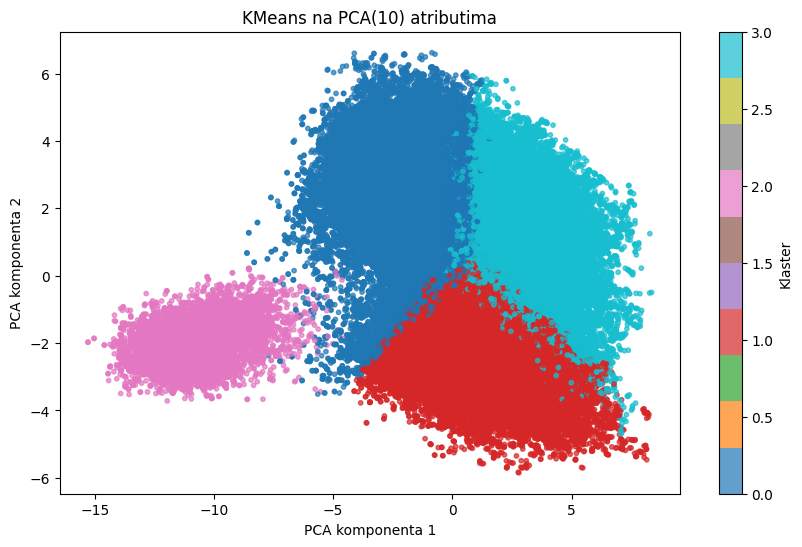

In [71]:
pca_vis = PCA(n_components=2, random_state=19)
X_pca10_vis = pca_vis.fit_transform(X_pca10)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_pca10_vis[:, 0],
    X_pca10_vis[:, 1],
    c=clusters_kmeans_pca,
    cmap="tab10",
    s=10,
    alpha=0.7
)
plt.title("KMeans na PCA(10) atributima")
plt.xlabel("PCA komponenta 1")
plt.ylabel("PCA komponenta 2")
plt.colorbar(label="Klaster")
plt.show()

In [72]:
final_compare = pd.DataFrame({
    "Model": ["KMeans (svi atributi)", "KMeans + PCA(10)"],
    "Silhouette": [0.174894, 0.223074],
    "Davies-Bouldin": [1.741409, 1.426499],
    "Calinski-Harabasz": [1497.299749, 1942.716410]
})

final_compare

,Model,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,KMeans (svi atributi),0.174894,1.741409,1497.299749
1,KMeans + PCA(10),0.223074,1.426499,1942.716410


In [73]:
cluster_profile = df.groupby("KMeans_cluster")[
    [
        "overall_rating",
        "gk_diving",
        "standing_tackle",
        "short_passing",
        "finishing",
        "sprint_speed"
    ]
].mean().round(2)

cluster_profile

,overall_rating,gk_diving,standing_tackle,short_passing,finishing,sprint_speed
KMeans_cluster,,,,,,
0,69.07,9.87,31.83,65.23,66.08,74.53
1,72.77,9.90,68.54,72.97,54.17,71.75
2,68.21,69.88,18.92,28.07,18.16,46.09
3,64.22,9.77,64.22,58.56,34.97,62.82


###### Tumačenje KMeans klastera

| Klaster | Tumačenje | Glavni atributi |
|---|---|---|
| 0 | Napadači / krila  | finishing, sprint_speed |
| 1 | Vezni igrači  | short_passing, overall_rating |
| 2 | Golmani  | gk_diving |
| 3 | Odbrambeni igrači  | standing_tackle |

In [74]:
df.to_csv("player_attributes_clean.csv", index=False)

##### Zaključak
 
U radu je izvršeno klasterovanje fudbalera korišćenjem pet različitih algoritama klasterovanja nad tabelom `Player_Attributes`.
Na osnovu elbow metode, silhouette koeficijenta i domenske interpretacije izabran je broj klastera `k=4`, koji prirodno odgovara podeli na:
- golmane,
- odbrambene igrače,
- vezne igrače,
- napadače.
 
Najstabilnije i najinterpretabilnije rezultate dao je algoritam **K-sredina**, dok je dodatna redukcija dimenzionalnosti pomoću **PCA sa 10 komponenti** dodatno poboljšala kvalitet klasterovanja po svim korišćenim internim metrikama.
 
Dobijeni rezultati potvrđuju da redukcija redundantnih atributa poboljšava separabilnost prirodnih grupa igrača i olakšava interpretaciju klastera.
